# K-Nearest Neighbors (Classification & Regression)

## Table of Contents
1. [Introduction](#1-introduction)
2. [Theory & Mathematics](#2-theory--mathematics)
3. [Assumptions & Requirements](#3-assumptions--requirements)
4. [When to Use This Algorithm](#4-when-to-use-this-algorithm)
5. [Implementation from Scratch (NumPy)](#5-implementation-from-scratch-numpy)
6. [Implementation with Scikit-learn](#6-implementation-with-scikit-learn)
7. [Hyperparameter Tuning](#7-hyperparameter-tuning)
8. [Complete Hyperparameter Reference](#8-complete-hyperparameter-reference)
9. [Practical Tips & Common Pitfalls](#9-practical-tips--common-pitfalls)
10. [Real-world Examples](#10-real-world-examples)
11. [Comparison with Other Algorithms](#11-comparison-with-other-algorithms)
12. [References](#12-references)


---

## 1. Introduction

### What is K-Nearest Neighbors (KNN)?

K-Nearest Neighbors is one of the simplest and most intuitive machine learning algorithms. It's a **non-parametric, instance-based** learning algorithm that makes predictions based on the k closest training examples in the feature space.

**Key characteristics:**
- **Supervised learning** algorithm for both classification and regression
- **Non-parametric** (makes no assumptions about data distribution)
- **Lazy learning** (no training phase - just stores data)
- **Instance-based** (uses training data directly for predictions)
- **Highly intuitive** - "You are the average of your k nearest neighbors"

**Historical Context:**
- Introduced by Evelyn Fix and Joseph Hodges in 1951
- Formalized by Thomas Cover and Peter Hart in 1967
- One of the oldest and simplest ML algorithms
- Still widely used as a baseline

**Main Use Cases:**
- **Classification**: Spam detection, recommendation systems, pattern recognition
- **Regression**: Price prediction, rating systems
- **Anomaly detection**: Finding outliers
- **Imputation**: Filling missing values
- **Similarity search**: Finding similar items

**How it works (simplified):**
1. Store all training data (no explicit training)
2. For a new point, calculate distances to all training points
3. Find the k nearest neighbors
4. **Classification**: Vote by majority class
5. **Regression**: Average the target values
6. Return the prediction

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score
)
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")


Libraries imported successfully!
NumPy version: 2.3.3
Pandas version: 2.3.3


---

## 2. Theory & Mathematics

### Core Concept: Distance-Based Learning

KNN operates on a simple principle: **similar data points should have similar labels/values**. It identifies similarity using distance metrics.

### Distance Metrics

**1. Euclidean Distance** (most common, L2 norm)

$$d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

- Measures straight-line distance
- Sensitive to scale
- Works well when all features are equally important

**2. Manhattan Distance** (L1 norm, City Block)

$$d(x, y) = \sum_{i=1}^{n} |x_i - y_i|$$

- Sum of absolute differences
- Less sensitive to outliers than Euclidean
- Good for grid-like paths

**3. Minkowski Distance** (generalized)

$$d(x, y) = \left(\sum_{i=1}^{n} |x_i - y_i|^p\right)^{1/p}$$

where:
- $p=1$: Manhattan distance
- $p=2$: Euclidean distance
- $p=\infty$: Chebyshev distance

**4. Cosine Similarity** (for text/high-dimensional data)

$$\text{similarity}(x, y) = \frac{x \cdot y}{||x|| \cdot ||y||}$$

### Classification Algorithm

**For a test point $x$:**

1. Calculate distances: $d(x, x_i)$ for all training points
2. Find k smallest distances
3. Get labels $y_1, y_2, ..., y_k$ of k nearest neighbors
4. **Uniform weights**: 
   $$\hat{y} = \text{mode}(y_1, ..., y_k)$$
5. **Distance weights**:
   $$\hat{y} = \arg\max_c \sum_{i=1}^{k} w_i \cdot \mathbb{1}(y_i = c)$$
   where $w_i = \frac{1}{d(x, x_i) + \epsilon}$

### Regression Algorithm

**For a test point $x$:**

1. Find k nearest neighbors
2. Get values $y_1, y_2, ..., y_k$
3. **Uniform weights**:
   $$\hat{y} = \frac{1}{k}\sum_{i=1}^{k} y_i$$
4. **Distance weights**:
   $$\hat{y} = \frac{\sum_{i=1}^{k} w_i \cdot y_i}{\sum_{i=1}^{k} w_i}$$
   where $w_i = \frac{1}{d(x, x_i) + \epsilon}$

### Curse of Dimensionality

In high dimensions:
- All points become roughly equidistant
- $d_{\text{max}} - d_{\text{min}} \to 0$ as dimensions increase
- KNN performance degrades
- Need exponentially more data

### Computational Complexity

- **Training**: O(1) - just stores data!
- **Prediction**: O(n × m) where n=samples, m=features
  - Calculate distance to each training point
  - Very slow for large datasets
- **Memory**: O(n × m) - stores all training data

### Optimization Techniques

1. **KD-Tree**: O(log n) for low dimensions (<20)
2. **Ball Tree**: O(log n) for moderate dimensions
3. **LSH (Locality Sensitive Hashing)**: Approximate for high dimensions


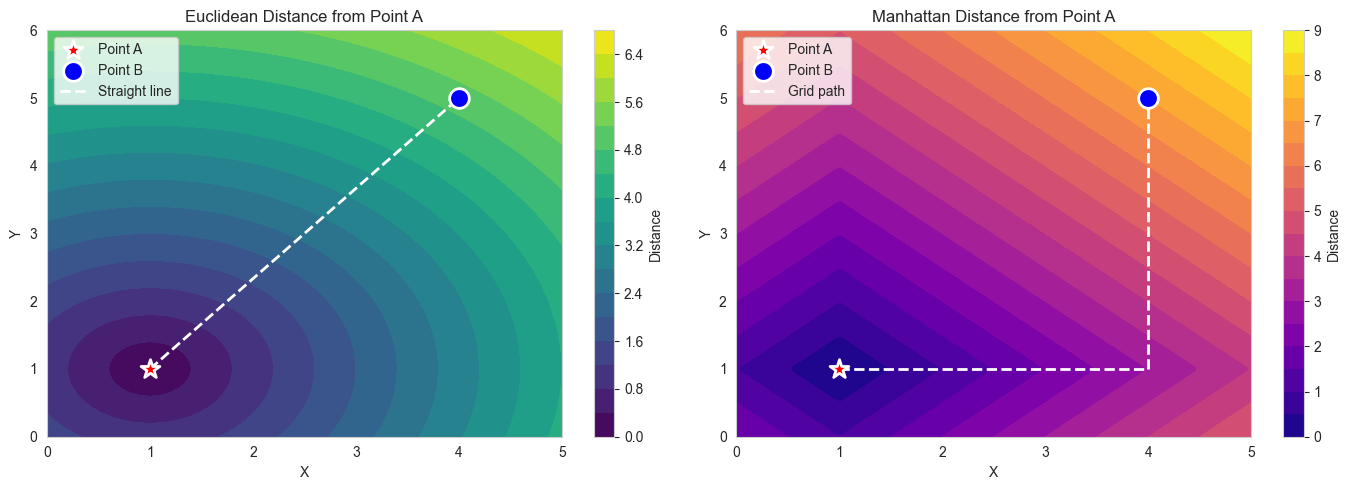

📏 Distance from [1 1] to [4 5]:
  • Euclidean: 5.00
  • Manhattan: 7.00
  • Ratio: 1.40x


In [2]:
# Visualize different distance metrics
np.random.seed(42)
point_a = np.array([1, 1])
point_b = np.array([4, 5])

# Create grid
x = np.linspace(0, 5, 100)
y = np.linspace(0, 6, 100)
X_grid, Y_grid = np.meshgrid(x, y)

# Calculate distances from point_a
euclidean_dist = np.sqrt((X_grid - point_a[0])**2 + (Y_grid - point_a[1])**2)
manhattan_dist = np.abs(X_grid - point_a[0]) + np.abs(Y_grid - point_a[1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Euclidean distance
contour1 = axes[0].contourf(X_grid, Y_grid, euclidean_dist, levels=20, cmap='viridis')
axes[0].scatter(*point_a, color='red', s=200, marker='*', edgecolors='white', linewidths=2, label='Point A', zorder=5)
axes[0].scatter(*point_b, color='blue', s=200, marker='o', edgecolors='white', linewidths=2, label='Point B', zorder=5)
axes[0].plot([point_a[0], point_b[0]], [point_a[1], point_b[1]], 'w--', linewidth=2, label='Straight line')
axes[0].set_title('Euclidean Distance from Point A')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].legend()
plt.colorbar(contour1, ax=axes[0], label='Distance')

# Manhattan distance
contour2 = axes[1].contourf(X_grid, Y_grid, manhattan_dist, levels=20, cmap='plasma')
axes[1].scatter(*point_a, color='red', s=200, marker='*', edgecolors='white', linewidths=2, label='Point A', zorder=5)
axes[1].scatter(*point_b, color='blue', s=200, marker='o', edgecolors='white', linewidths=2, label='Point B', zorder=5)
# Manhattan path
axes[1].plot([point_a[0], point_b[0]], [point_a[1], point_a[1]], 'w--', linewidth=2)
axes[1].plot([point_b[0], point_b[0]], [point_a[1], point_b[1]], 'w--', linewidth=2, label='Grid path')
axes[1].set_title('Manhattan Distance from Point A')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
axes[1].legend()
plt.colorbar(contour2, ax=axes[1], label='Distance')

plt.tight_layout()
plt.show()

# Calculate actual distances
euc_dist = np.sqrt((point_b[0] - point_a[0])**2 + (point_b[1] - point_a[1])**2)
man_dist = np.abs(point_b[0] - point_a[0]) + np.abs(point_b[1] - point_a[1])

print(f"📏 Distance from {point_a} to {point_b}:")
print(f"  • Euclidean: {euc_dist:.2f}")
print(f"  • Manhattan: {man_dist:.2f}")
print(f"  • Ratio: {man_dist/euc_dist:.2f}x")


---

## 3. Assumptions & Requirements

### Minimal Assumptions (Major Advantage!)

KNN makes very few assumptions, but has important requirements:

✅ **No assumptions about:**
- Data distribution
- Linear relationships
- Feature independence
- Parametric form

### What KNN DOES Require:

1. **Meaningful Distance Metric**
   - Features must be on comparable scales
   - Distance should represent similarity
   - **Critical**: Always scale features!

2. **Sufficient Training Data**
   - Need dense coverage of feature space
   - Performance degrades in sparse regions
   - More data = better predictions

3. **Low to Moderate Dimensions**
   - Curse of dimensionality in high dimensions
   - Typically works well up to ~20 features
   - Beyond that, consider dimensionality reduction

4. **Computational Resources**
   - O(n) prediction time per sample
   - Stores entire training set in memory
   - Can be slow for large datasets

### Feature Scaling is CRITICAL!

**Why**: Features on different scales will dominate distance calculations.

**Example**:
- Age: [20-70] (range: 50)
- Income: [20,000-200,000] (range: 180,000)
- Distance will be dominated by income!

**Solution**: Always standardize features!

```python
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
```

### Key Differences from Other Algorithms

| Aspect | KNN | Decision Trees | Linear Models |
|--------|-----|----------------|---------------|
| **Training Time** | O(1) - instant! | O(n log n) | O(n × m) |
| **Prediction Time** | O(n) - slow! | O(log n) - fast | O(m) - fast |
| **Memory** | O(n × m) - large | O(nodes) - small | O(m) - tiny |
| **Feature Scaling** | **Required** | Not needed | Required |
| **Interpretability** | Low (black box) | High (visual) | High (coefficients) |
| **Non-linear** | Yes | Yes | No |


---

## 4. When to Use This Algorithm

### ✅ Use KNN When:

1. **Small to Medium Datasets**
   - <10,000 samples (prediction speed manageable)
   - Dense feature space
   - Enough memory to store training data

2. **No Training Time Constraints**
   - Instant training (just stores data)
   - Model needs frequent updates
   - Online learning scenarios

3. **Non-linear Relationships**
   - Decision boundaries are complex
   - Linear models fail
   - Data has local patterns

4. **Low Dimensionality**
   - <20 features typically
   - Or after dimensionality reduction (PCA, etc.)

5. **Need Simple Baseline**
   - Quick to implement
   - No hyperparameters to tune (just k)
   - Good sanity check

6. **Anomaly Detection**
   - Find outliers (far from neighbors)
   - Detect unusual patterns
   - Novelty detection

7. **Recommendation Systems**
   - Find similar items/users
   - Collaborative filtering
   - "Customers who bought X also bought..."

### ❌ Avoid KNN When:

1. **Large Datasets**
   - >100,000 samples (too slow)
   - O(n) prediction time per sample
   - Consider approximations (LSH) or other algorithms

2. **High Dimensionality**
   - >50 features (curse of dimensionality)
   - All points become equidistant
   - Use dimensionality reduction first

3. **Real-time Predictions Required**
   - Prediction is O(n) - slow!
   - Use faster algorithms (trees, linear models)
   - Or pre-compute with KD-Trees

4. **Memory Constraints**
   - Stores entire training set
   - Not suitable for embedded systems
   - Consider model compression

5. **Imbalanced Classes**
   - Majority class dominates voting
   - Need to balance or weight classes
   - Other algorithms handle this better

6. **Feature Scales Vary Wildly**
   - **MUST** scale features
   - If you can't/won't scale, don't use KNN
   - Decision trees don't need scaling

### Classification vs Regression

| Task Type | When to Use KNN |
|-----------|-----------------|
| **Classification** | ✅ Multi-class problems<br>✅ Non-linear decision boundaries<br>✅ Local patterns important<br>⚠️ Need probability estimates (coarse) |
| **Regression** | ✅ Non-linear relationships<br>✅ Local averaging appropriate<br>⚠️ Smooth predictions (piecewise constant)<br>❌ Extrapolation required |

### KNN vs Other Algorithms

**vs Decision Trees:**
- KNN: Slower prediction, no training, needs scaling
- Trees: Faster prediction, training time, no scaling needed

**vs SVM:**
- KNN: Simpler, no kernel tricks, memory intensive
- SVM: More complex, kernel methods, more efficient

**vs Neural Networks:**
- KNN: No training, interpretable neighbors, small data
- NN: Training required, black box, needs more data

**vs Naive Bayes:**
- KNN: No independence assumption, slower
- NB: Assumes independence, very fast


---

## 5. Implementation from Scratch (NumPy)

Let's implement both KNN Classifier and Regressor from scratch to understand the internals.


In [3]:
# Import our from-scratch implementations
import sys
sys.path.append('../src')

from models.knn_models import KNNClassifierScratch, KNNRegressorScratch

print("✅ Imported custom KNN implementations!")
print("\nAvailable classes:")
print("  • KNNClassifierScratch")
print("  • KNNRegressorScratch")


✅ Imported custom KNN implementations!

Available classes:
  • KNNClassifierScratch
  • KNNRegressorScratch


### Classification Example (From Scratch)


In [4]:
# Generate classification dataset
from sklearn.datasets import make_classification

X_clf, y_clf = make_classification(
    n_samples=500,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    n_classes=2,
    random_state=42
)

# Split data
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

# IMPORTANT: Scale features for KNN!
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

print("=" * 60)
print("KNN CLASSIFIER (FROM SCRATCH)")
print("=" * 60)
print(f"\n📊 Dataset:")
print(f"  Training samples: {len(X_train_clf)}")
print(f"  Test samples: {len(X_test_clf)}")
print(f"  Features: {X_train_clf.shape[1]}")
print(f"  Classes: {len(np.unique(y_clf))}")

# Train model with different metrics
print("\n🔍 Testing different distance metrics...")

for metric in ['euclidean', 'manhattan']:
    knn_scratch = KNNClassifierScratch(
        n_neighbors=5,
        metric=metric,
        weights='uniform'
    )
    knn_scratch.fit(X_train_clf_scaled, y_train_clf)
    
    train_score = knn_scratch.score(X_train_clf_scaled, y_train_clf)
    test_score = knn_scratch.score(X_test_clf_scaled, y_test_clf)
    
    print(f"\n{metric.capitalize()} Distance:")
    print(f"  Train Accuracy: {train_score:.4f}")
    print(f"  Test Accuracy:  {test_score:.4f}")

# Test weighted vs uniform
print("\n⚖️ Testing uniform vs distance weights...")
for weights in ['uniform', 'distance']:
    knn_scratch = KNNClassifierScratch(
        n_neighbors=5,
        metric='euclidean',
        weights=weights
    )
    knn_scratch.fit(X_train_clf_scaled, y_train_clf)
    test_score = knn_scratch.score(X_test_clf_scaled, y_test_clf)
    
    print(f"  {weights.capitalize()}: {test_score:.4f}")


KNN CLASSIFIER (FROM SCRATCH)

📊 Dataset:
  Training samples: 400
  Test samples: 100
  Features: 10
  Classes: 2

🔍 Testing different distance metrics...

Euclidean Distance:
  Train Accuracy: 0.9350
  Test Accuracy:  0.8600

Manhattan Distance:
  Train Accuracy: 0.9375
  Test Accuracy:  0.8500

⚖️ Testing uniform vs distance weights...
  Uniform: 0.8600
  Distance: 0.8600


### Regression Example (From Scratch)


In [5]:
# Generate regression dataset
from sklearn.datasets import make_regression

X_reg, y_reg = make_regression(
    n_samples=500,
    n_features=10,
    n_informative=5,
    noise=10,
    random_state=42
)

# Split data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# IMPORTANT: Scale features for KNN!
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

print("=" * 60)
print("KNN REGRESSOR (FROM SCRATCH)")
print("=" * 60)
print(f"\n📊 Dataset:")
print(f"  Training samples: {len(X_train_reg)}")
print(f"  Test samples: {len(X_test_reg)}")
print(f"  Features: {X_train_reg.shape[1]}")

# Train model
knn_reg_scratch = KNNRegressorScratch(
    n_neighbors=5,
    metric='euclidean',
    weights='uniform'
)
knn_reg_scratch.fit(X_train_reg_scaled, y_train_reg)

# Predictions
y_train_pred_scratch = knn_reg_scratch.predict(X_train_reg_scaled)
y_test_pred_scratch = knn_reg_scratch.predict(X_test_reg_scaled)

# Evaluate
train_r2 = knn_reg_scratch.score(X_train_reg_scaled, y_train_reg)
test_r2 = knn_reg_scratch.score(X_test_reg_scaled, y_test_reg)
train_rmse = np.sqrt(mean_squared_error(y_train_reg, y_train_pred_scratch))
test_rmse = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_scratch))

print("\n📈 Results:")
print(f"  Train R²:   {train_r2:.4f}")
print(f"  Test R²:    {test_r2:.4f}")
print(f"  Train RMSE: {train_rmse:.2f}")
print(f"  Test RMSE:  {test_rmse:.2f}")

print("\n💡 Note: KNN stores all training data (no actual training!)")


KNN REGRESSOR (FROM SCRATCH)

📊 Dataset:
  Training samples: 400
  Test samples: 100
  Features: 10

📈 Results:
  Train R²:   0.8254
  Test R²:    0.7570
  Train RMSE: 27.41
  Test RMSE:  33.00

💡 Note: KNN stores all training data (no actual training!)


---

## 6. Implementation with Scikit-learn

Now let's use scikit-learn's optimized implementations for both classification and regression.

### Classification with Scikit-learn


KNN CLASSIFIER (SCIKIT-LEARN)

📈 Performance:
  Train Accuracy: 0.9350
  Test Accuracy:  0.8600
  Precision:      0.8913
  Recall:         0.8200
  F1-Score:       0.8542


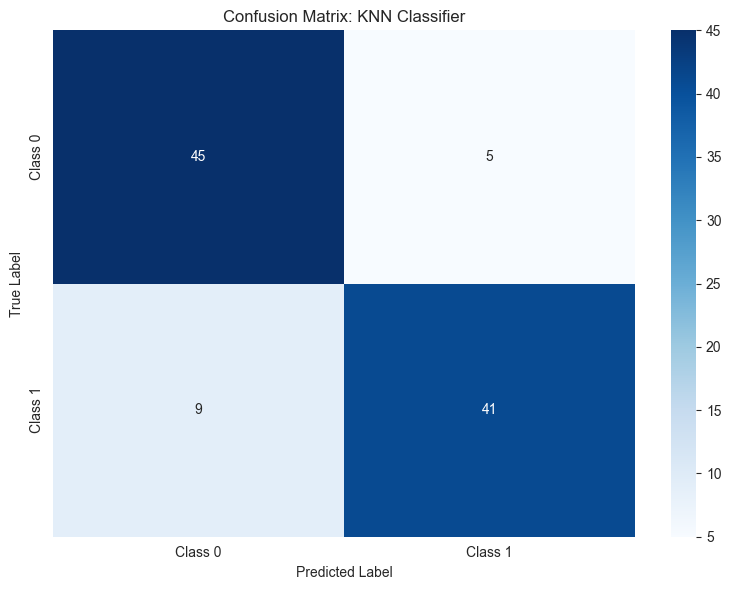


⚠️ Important: KNN stored 400 training samples in memory!


In [6]:
# Use same classification data from before
print("=" * 60)
print("KNN CLASSIFIER (SCIKIT-LEARN)")
print("=" * 60)

# Train model
knn_clf_sk = KNeighborsClassifier(
    n_neighbors=5,
    metric='euclidean',
    weights='uniform'
)
knn_clf_sk.fit(X_train_clf_scaled, y_train_clf)

# Predictions
y_train_pred_clf = knn_clf_sk.predict(X_train_clf_scaled)
y_test_pred_clf = knn_clf_sk.predict(X_test_clf_scaled)
y_test_proba_clf = knn_clf_sk.predict_proba(X_test_clf_scaled)

# Evaluate
train_acc = accuracy_score(y_train_clf, y_train_pred_clf)
test_acc = accuracy_score(y_test_clf, y_test_pred_clf)
precision = precision_score(y_test_clf, y_test_pred_clf)
recall = recall_score(y_test_clf, y_test_pred_clf)
f1 = f1_score(y_test_clf, y_test_pred_clf)

print("\n📈 Performance:")
print(f"  Train Accuracy: {train_acc:.4f}")
print(f"  Test Accuracy:  {test_acc:.4f}")
print(f"  Precision:      {precision:.4f}")
print(f"  Recall:         {recall:.4f}")
print(f"  F1-Score:       {f1:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test_clf, y_test_pred_clf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix: KNN Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(f"\n⚠️ Important: KNN stored {len(X_train_clf)} training samples in memory!")


### Regression with Scikit-learn


KNN REGRESSOR (SCIKIT-LEARN)

📈 Performance:
  Train R²:   0.8254
  Test R²:    0.7570
  Train RMSE: 27.41
  Test RMSE:  33.00
  Test MAE:   25.74


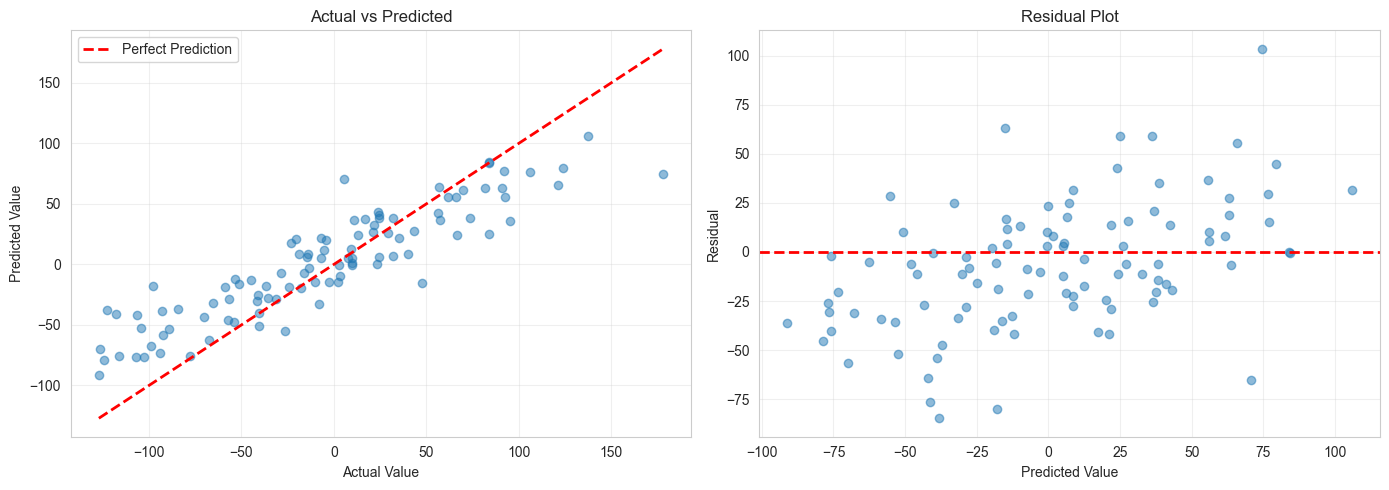


⚠️ Prediction time scales with training set size: O(400)


In [7]:
# Use same regression data from before
print("=" * 60)
print("KNN REGRESSOR (SCIKIT-LEARN)")
print("=" * 60)

# Train model
knn_reg_sk = KNeighborsRegressor(
    n_neighbors=5,
    metric='euclidean',
    weights='uniform'
)
knn_reg_sk.fit(X_train_reg_scaled, y_train_reg)

# Predictions
y_train_pred_reg = knn_reg_sk.predict(X_train_reg_scaled)
y_test_pred_reg = knn_reg_sk.predict(X_test_reg_scaled)

# Evaluate
train_r2 = r2_score(y_train_reg, y_train_pred_reg)
test_r2 = r2_score(y_test_reg, y_test_pred_reg)
train_rmse = np.sqrt(mean_squared_error(y_train_reg, y_train_pred_reg))
test_rmse = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_reg))
test_mae = mean_absolute_error(y_test_reg, y_test_pred_reg)

print("\n📈 Performance:")
print(f"  Train R²:   {train_r2:.4f}")
print(f"  Test R²:    {test_r2:.4f}")
print(f"  Train RMSE: {train_rmse:.2f}")
print(f"  Test RMSE:  {test_rmse:.2f}")
print(f"  Test MAE:   {test_mae:.2f}")

# Visualize predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test_reg, y_test_pred_reg, alpha=0.5)
axes[0].plot([y_test_reg.min(), y_test_reg.max()],
            [y_test_reg.min(), y_test_reg.max()],
            'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Value')
axes[0].set_ylabel('Predicted Value')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals
residuals = y_test_reg - y_test_pred_reg
axes[1].scatter(y_test_pred_reg, residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Value')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n⚠️ Prediction time scales with training set size: O({len(X_train_reg)})")


---

## 7. Hyperparameter Tuning

The most important hyperparameter for KNN is `n_neighbors` (k). Let's find the optimal value.


In [8]:
# Grid Search for Classification
print("=" * 60)
print("HYPERPARAMETER TUNING - CLASSIFICATION")
print("=" * 60)

param_grid_clf = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 15, 20],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search_clf = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_clf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print("\n🔍 Searching through parameter combinations...")
grid_search_clf.fit(X_train_clf_scaled, y_train_clf)

print("\n✅ Best Parameters:")
for param, value in grid_search_clf.best_params_.items():
    print(f"  {param}: {value}")

print(f"\n📈 Best CV Accuracy: {grid_search_clf.best_score_:.4f}")

# Test best model
best_model_clf = grid_search_clf.best_estimator_
test_score_best = best_model_clf.score(X_test_clf_scaled, y_test_clf)
print(f"Test Accuracy: {test_score_best:.4f}")


HYPERPARAMETER TUNING - CLASSIFICATION

🔍 Searching through parameter combinations...

✅ Best Parameters:
  metric: manhattan
  n_neighbors: 11
  weights: uniform

📈 Best CV Accuracy: 0.9225
Test Accuracy: 0.8700


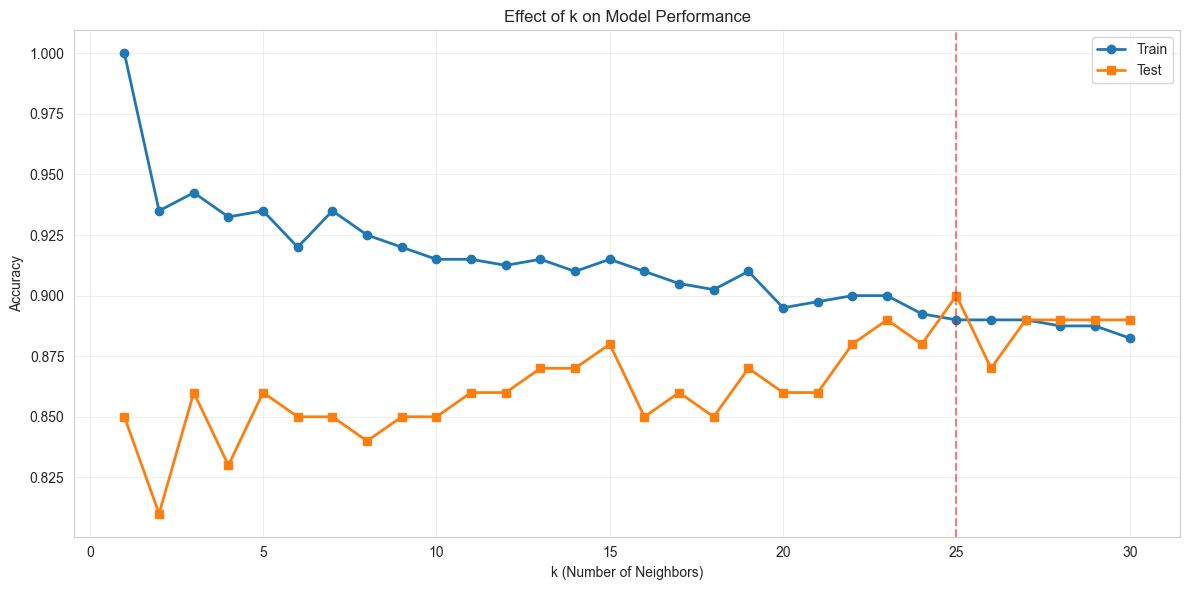

💡 Observations:
  • k=1: Perfect train accuracy (overfitting), lower test accuracy
  • k increases: Train accuracy decreases, test accuracy stabilizes
  • Best k for test: 25
  • Too large k: Underfitting (model too simple)
  • Rule of thumb: k ≈ sqrt(n_samples) = 20


In [9]:
# Visualize effect of k on performance
k_values = range(1, 31)
train_scores_k = []
test_scores_k = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_clf_scaled, y_train_clf)
    train_scores_k.append(knn_temp.score(X_train_clf_scaled, y_train_clf))
    test_scores_k.append(knn_temp.score(X_test_clf_scaled, y_test_clf))

plt.figure(figsize=(12, 6))
plt.plot(k_values, train_scores_k, 'o-', label='Train', linewidth=2)
plt.plot(k_values, test_scores_k, 's-', label='Test', linewidth=2)
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('Effect of k on Model Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axvline(x=k_values[np.argmax(test_scores_k)], color='red', linestyle='--', alpha=0.5, label='Best k')
plt.tight_layout()
plt.show()

print("💡 Observations:")
print(f"  • k=1: Perfect train accuracy (overfitting), lower test accuracy")
print(f"  • k increases: Train accuracy decreases, test accuracy stabilizes")
print(f"  • Best k for test: {k_values[np.argmax(test_scores_k)]}")
print(f"  • Too large k: Underfitting (model too simple)")
print(f"  • Rule of thumb: k ≈ sqrt(n_samples) = {int(np.sqrt(len(X_train_clf)))}")


---

## 8. Complete Hyperparameter Reference

### K-Nearest Neighbors Parameters

#### `n_neighbors` (int, default=5) **[MOST IMPORTANT]**
- **Description**: Number of neighbors to use
- **Effect on Model**:
  - **Small k** (e.g., 1-3): 
    - More complex model
    - Sensitive to noise
    - Overfits easily
    - Wiggly decision boundaries
  - **Large k** (e.g., 20-50):
    - Simpler model
    - Smoother decision boundaries
    - May underfit
    - Less sensitive to noise
- **Typical Range**: [1, 3, 5, 7, 9, 11, 15, 20]
- **Tuning Strategy**:
  1. Try odd numbers (avoid ties in binary classification)
  2. Start with k=5
  3. Rule of thumb: k ≈ sqrt(n_samples)
  4. Use cross-validation
- **Example**: `KNeighborsClassifier(n_neighbors=7)`

---

#### `weights` (str or callable, default='uniform')
- **Options**: 'uniform', 'distance', callable
- **Effect**:
  - **'uniform'**: All neighbors have equal weight
    - Simple majority vote/average
    - Works well when neighbors are roughly equidistant
  - **'distance'**: Closer neighbors have more influence
    - Weight = 1 / distance
    - Better when distances vary significantly
    - Reduces impact of outliers
  - **callable**: Custom weight function
- **When to use 'distance'**: 
  - Varying neighbor distances
  - Want smooth transitions
  - Reduce noise impact
- **Example**: `KNeighborsClassifier(weights='distance')`

---

#### `metric` (str or callable, default='minkowski')
- **Options**: 'euclidean', 'manhattan', 'minkowski', 'chebyshev', 'cosine', etc.
- **Common Metrics**:
  - **'euclidean'** (p=2): Straight-line distance
    - Most common
    - Sensitive to scale
  - **'manhattan'** (p=1): Grid-like distance
    - Less sensitive to outliers
    - Good for high-dimensional data
  - **'minkowski'**: Generalized (requires p parameter)
  - **'cosine'**: Angle-based similarity
    - Good for text/sparse data
    - Scale-invariant
- **Example**: `KNeighborsClassifier(metric='manhattan')`

---

#### `p` (int, default=2)
- **Description**: Power parameter for Minkowski distance
- **Effect**:
  - p=1: Manhattan distance
  - p=2: Euclidean distance
  - p=∞: Chebyshev distance
- **Example**: `KNeighborsClassifier(metric='minkowski', p=1)`

---

#### `algorithm` (str, default='auto')
- **Options**: 'auto', 'ball_tree', 'kd_tree', 'brute'
- **Effect on Speed**:
  - **'brute'**: O(n) - slow but always works
  - **'kd_tree'**: O(log n) - fast for low dimensions (<20)
  - **'ball_tree'**: O(log n) - faster for moderate dimensions
  - **'auto'**: Chooses best based on data
- **When to specify**:
  - Large datasets: Use 'ball_tree' or 'kd_tree'
  - High dimensions (>50): Use 'brute'
  - Small datasets: Doesn't matter
- **Example**: `KNeighborsClassifier(algorithm='ball_tree')`

---

#### `leaf_size` (int, default=30)
- **Description**: Leaf size for Ball Tree or KD Tree
- **Effect**:
  - Smaller: More memory, faster queries
  - Larger: Less memory, slower queries
- **Typical Range**: [10, 30, 50]
- **Only affects** tree-based algorithms
- **Example**: `KNeighborsClassifier(leaf_size=40)`

---

#### `n_jobs` (int, default=None)
- **Description**: Number of parallel jobs
- **Options**:
  - None: Single core
  - -1: Use all cores
  - n: Use n cores
- **Effect**: Speeds up prediction on large datasets
- **Example**: `KNeighborsClassifier(n_jobs=-1)`

---

### Parameter Combinations Guide

#### For Standard Classification:
```python
KNeighborsClassifier(
    n_neighbors=5,
    weights='uniform',
    metric='euclidean',
    algorithm='auto'
)
```

#### For Noisy Data:
```python
KNeighborsClassifier(
    n_neighbors=11,  # Higher k for smoothing
    weights='distance',  # Weight by distance
    metric='euclidean'
)
```

#### For High-Dimensional Data:
```python
KNeighborsClassifier(
    n_neighbors=7,
    metric='manhattan',  # Better for high dimensions
    algorithm='brute'  # KD-tree ineffective
)
```

#### For Large Datasets:
```python
KNeighborsClassifier(
    n_neighbors=5,
    algorithm='ball_tree',  # Fast queries
    n_jobs=-1  # Parallel processing
)
```

#### For Text/Sparse Data:
```python
KNeighborsClassifier(
    n_neighbors=5,
    metric='cosine',  # Angle-based
    algorithm='brute'  # Required for cosine
)
```

#### For Standard Regression:
```python
KNeighborsRegressor(
    n_neighbors=5,
    weights='distance',  # Usually better for regression
    metric='euclidean'
)
```


---

## 9. Practical Tips & Common Pitfalls

### ✅ Best Practices

#### 1. **ALWAYS Scale Features** (CRITICAL!)
KNN is extremely sensitive to feature scales.

```python
# Bad: Features on different scales
knn.fit(X_train, y_train)  # Age: [20-70], Income: [20k-200k] → Income dominates!

# Good: Standardize features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn.fit(X_train_scaled, y_train)
```

---

#### 2. **Choose k Wisely**
```python
# Start with k=5 or k=sqrt(n_samples)
k_suggested = int(np.sqrt(len(X_train)))

# Use odd k for binary classification (avoid ties)
if k_suggested % 2 == 0:
    k_suggested += 1

knn = KNeighborsClassifier(n_neighbors=k_suggested)
```

---

#### 3. **Use Distance Weights for Regression**
```python
# For regression, distance weighting usually helps
knn_reg = KNeighborsRegressor(weights='distance')
```

---

#### 4. **Handle High Dimensions**
```python
# If >50 features, use dimensionality reduction first
from sklearn.decomposition import PCA

pca = PCA(n_components=20)
X_reduced = pca.fit_transform(X)

knn = KNeighborsClassifier()
knn.fit(X_reduced, y)
```

---

#### 5. **Optimize for Large Datasets**
```python
# Use Ball Tree or KD Tree
knn = KNeighborsClassifier(
    algorithm='ball_tree',
    n_jobs=-1  # Parallel processing
)
```

---

#### 6. **Cross-Validate k**
```python
from sklearn.model_selection import cross_val_score

k_values = range(1, 21, 2)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5)
    cv_scores.append(scores.mean())

best_k = k_values[np.argmax(cv_scores)]
```

---

### ❌ Common Mistakes

#### 1. **Forgetting to Scale Features** (MOST COMMON!)
**Bad**:
```python
# Feature 1: Age [20-70]
# Feature 2: Income [20000-200000]
knn = KNeighborsClassifier()
knn.fit(X, y)  # Income will dominate distance!
```

**Good**:
```python
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
knn.fit(X_scaled, y)
```

---

#### 2. **Using KNN on Large Datasets**
**Bad**:
```python
# 1 million samples - very slow predictions!
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)  # O(1M) per prediction!
```

**Good**:
```python
# Use faster algorithms or subsample
from sklearn.utils import resample
X_sample, y_sample = resample(X_train, y_train, n_samples=10000)
knn.fit(X_sample, y_sample)

# Or use approximations
knn = KNeighborsClassifier(algorithm='ball_tree')
```

---

#### 3. **Using k=1 (Overfitting)**
```python
# Bad: k=1 memorizes training data
knn = KNeighborsClassifier(n_neighbors=1)
# Train accuracy: 100%, Test accuracy: 70%

# Good: Use cross-validation to find optimal k
knn = KNeighborsClassifier(n_neighbors=7)
```

---

#### 4. **Ignoring Curse of Dimensionality**
```python
# Bad: 500 features, 1000 samples
X = np.random.rand(1000, 500)
knn = KNeighborsClassifier()
knn.fit(X, y)  # All points become equidistant!

# Good: Reduce dimensions first
from sklearn.decomposition import PCA
pca = PCA(n_components=20)
X_reduced = pca.fit_transform(X)
knn.fit(X_reduced, y)
```

---

#### 5. **Not Handling Imbalanced Data**
```python
# Bad: 95% class 0, 5% class 1
knn = KNeighborsClassifier(n_neighbors=10)
# Will always predict class 0!

# Good: Use smaller k or balance data
from imblearn.over_sampling import SMOTE
smote = SMOTE()
X_balanced, y_balanced = smote.fit_resample(X, y)

# Or use weighted voting
knn = KNeighborsClassifier(n_neighbors=5, weights='distance')
```

---

#### 6. **Using Wrong Distance Metric**
```python
# Bad: Euclidean for text data
knn = KNeighborsClassifier(metric='euclidean')

# Good: Cosine similarity for text
knn = KNeighborsClassifier(metric='cosine', algorithm='brute')
```

---

### Performance Optimization

#### Computational Complexity
- **Training**: O(1) - just stores data (instant!)
- **Prediction**: O(n × m) where n=samples, m=features
  - Very slow for large n
  - Bottleneck is distance calculation
- **Memory**: O(n × m) - stores entire training set

#### Speed Optimization Techniques

**1. Use Tree-Based Algorithms**
```python
# KD-Tree (good for <20 dimensions)
knn = KNeighborsClassifier(algorithm='kd_tree')

# Ball Tree (better for moderate dimensions)
knn = KNeighborsClassifier(algorithm='ball_tree')
```

**2. Reduce Dimensions**
```python
from sklearn.decomposition import PCA
pca = PCA(n_components=10)
X_reduced = pca.fit_transform(X)
```

**3. Subsample Training Data**
```python
# Use only representative subset
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=1000)
centroids = kmeans.fit_predict(X_train)
# Use centroids as training data
```

**4. Approximate Nearest Neighbors**
```python
# Use libraries like FAISS, Annoy, or HNSW
# For very large datasets
```

---

### Debugging Tips

#### Model Not Learning?
1. **Check if features are scaled**
2. **Try different k values**
3. **Check for sufficient data density**
4. **Verify distance metric makes sense**

#### Too Slow?
1. **Use algorithm='ball_tree'**
2. **Reduce dimensions with PCA**
3. **Subsample training data**
4. **Use approximate methods**

#### Poor Performance?
1. **Scale features!**
2. **Try different distance metrics**
3. **Tune k with cross-validation**
4. **Check for curse of dimensionality**
5. **Consider feature engineering**


---

## 10. Real-world Examples

### Example 1: Handwritten Digit Recognition (Classification)


REAL-WORLD EXAMPLE: HANDWRITTEN DIGIT RECOGNITION

📊 Dataset:
  Total samples: 1797
  Training: 1257
  Test: 540
  Features: 64 (8x8 pixel images)
  Classes: 10 (digits 0-9)


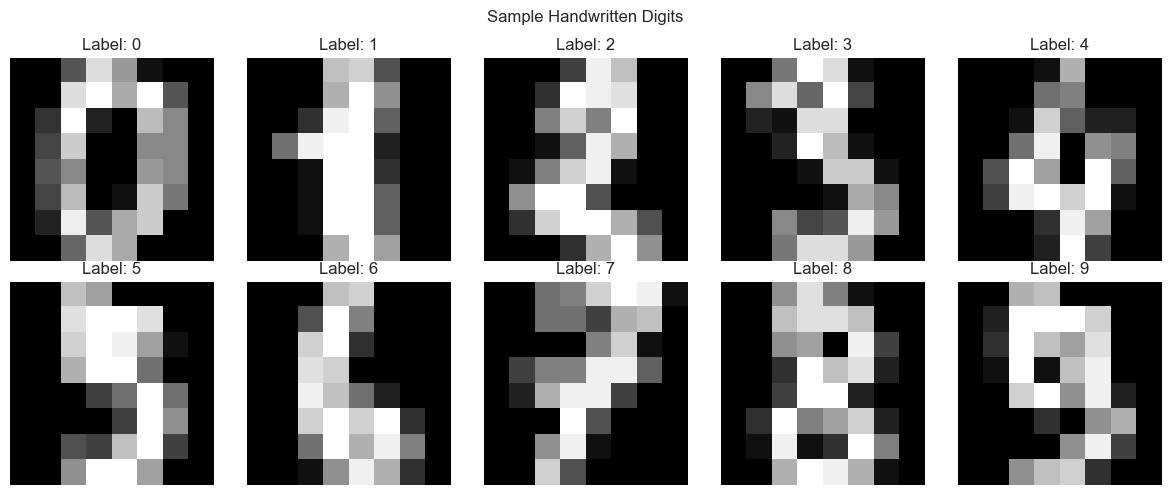

In [10]:
# Load digits dataset (8x8 images)
from sklearn.datasets import load_digits

digits = load_digits()
X_digits = digits.data  # 64 features (8x8 pixels)
y_digits = digits.target  # 0-9 classes

# Split data
X_train_digits, X_test_digits, y_train_digits, y_test_digits = train_test_split(
    X_digits, y_digits, test_size=0.3, random_state=42, stratify=y_digits
)

# Scale features (pixel values already 0-16, but let's standardize)
scaler_digits = StandardScaler()
X_train_digits_scaled = scaler_digits.fit_transform(X_train_digits)
X_test_digits_scaled = scaler_digits.transform(X_test_digits)

print("=" * 60)
print("REAL-WORLD EXAMPLE: HANDWRITTEN DIGIT RECOGNITION")
print("=" * 60)
print(f"\n📊 Dataset:")
print(f"  Total samples: {len(X_digits)}")
print(f"  Training: {len(X_train_digits)}")
print(f"  Test: {len(X_test_digits)}")
print(f"  Features: {X_digits.shape[1]} (8x8 pixel images)")
print(f"  Classes: {len(np.unique(y_digits))} (digits 0-9)")

# Visualize some digits
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for idx, ax in enumerate(axes.flat):
    ax.imshow(X_digits[idx].reshape(8, 8), cmap='gray')
    ax.set_title(f'Label: {y_digits[idx]}')
    ax.axis('off')
plt.suptitle('Sample Handwritten Digits')
plt.tight_layout()
plt.show()



🔍 Testing different k values...
k=1: Train=1.0000, Test=0.9741
k=3: Train=1.0000, Test=0.9741
k=5: Train=1.0000, Test=0.9722
k=7: Train=1.0000, Test=0.9704
k=9: Train=1.0000, Test=0.9667

📈 Best Model (k=3) Performance:
  Test Accuracy: 0.9741


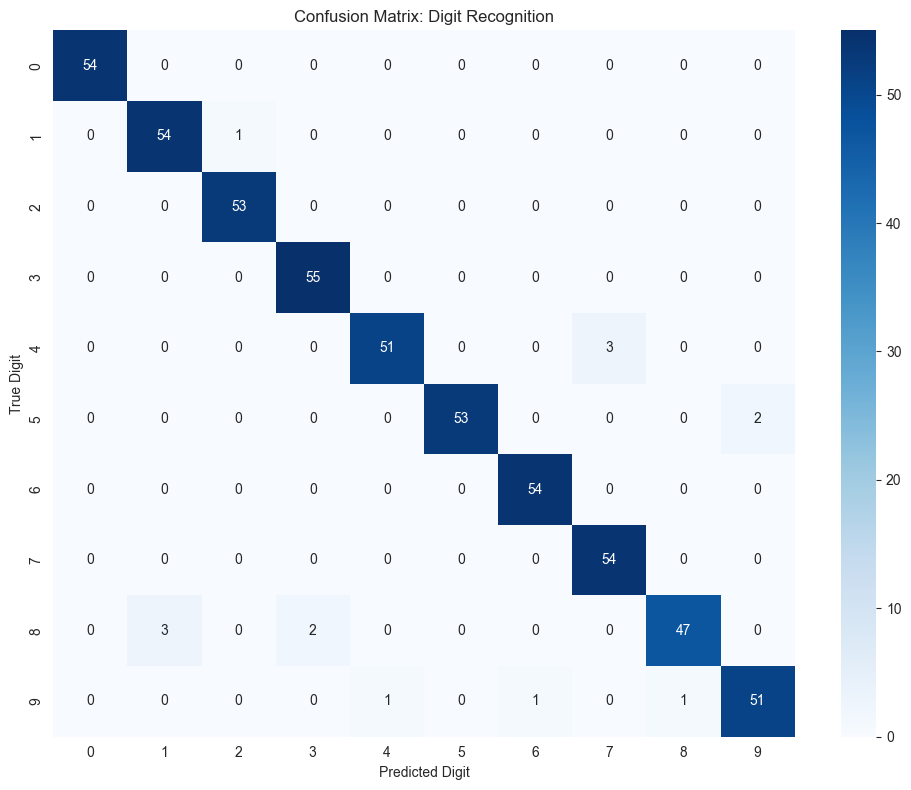

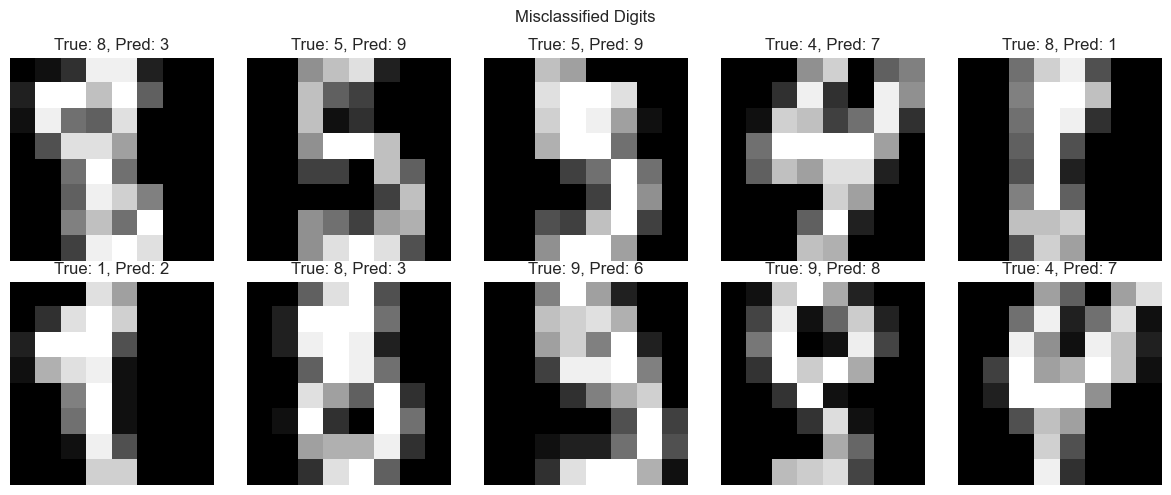


💡 KNN works well for image recognition!
   • Similar pixels → similar digits
   • Distance in pixel space = visual similarity
   • Misclassifications often look similar (e.g., 3 vs 8)


In [11]:
# Train KNN with different k values
print("\n🔍 Testing different k values...")

k_values_test = [1, 3, 5, 7, 9]
results_digits = []

for k in k_values_test:
    knn_digits = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn_digits.fit(X_train_digits_scaled, y_train_digits)
    
    train_acc = knn_digits.score(X_train_digits_scaled, y_train_digits)
    test_acc = knn_digits.score(X_test_digits_scaled, y_test_digits)
    
    results_digits.append({
        'k': k,
        'Train Acc': train_acc,
        'Test Acc': test_acc
    })
    
    print(f"k={k}: Train={train_acc:.4f}, Test={test_acc:.4f}")

# Use best model
best_k_digits = 3
knn_best_digits = KNeighborsClassifier(n_neighbors=best_k_digits, weights='distance')
knn_best_digits.fit(X_train_digits_scaled, y_train_digits)

y_pred_digits = knn_best_digits.predict(X_test_digits_scaled)

print(f"\n📈 Best Model (k={best_k_digits}) Performance:")
print(f"  Test Accuracy: {accuracy_score(y_test_digits, y_pred_digits):.4f}")

# Confusion matrix
cm_digits = confusion_matrix(y_test_digits, y_pred_digits)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_digits, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix: Digit Recognition')
plt.ylabel('True Digit')
plt.xlabel('Predicted Digit')
plt.tight_layout()
plt.show()

# Show some misclassifications
misclassified_idx = np.where(y_pred_digits != y_test_digits)[0][:10]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for idx, ax in enumerate(axes.flat):
        if idx < len(misclassified_idx):
            img_idx = misclassified_idx[idx]
            ax.imshow(X_test_digits[img_idx].reshape(8, 8), cmap='gray')
            ax.set_title(f'True: {y_test_digits[img_idx]}, Pred: {y_pred_digits[img_idx]}')
        ax.axis('off')
    plt.suptitle('Misclassified Digits')
    plt.tight_layout()
    plt.show()

print(f"\n💡 KNN works well for image recognition!")
print(f"   • Similar pixels → similar digits")
print(f"   • Distance in pixel space = visual similarity")
print(f"   • Misclassifications often look similar (e.g., 3 vs 8)")


### Example 2: Housing Price Prediction (Regression)


In [12]:
# Simulate housing dataset
np.random.seed(42)

n_houses = 500
sqft = np.random.randint(800, 4000, n_houses)
bedrooms = np.random.randint(1, 6, n_houses)
bathrooms = np.random.randint(1, 4, n_houses)
age = np.random.randint(0, 50, n_houses)
distance_downtown = np.random.uniform(1, 20, n_houses)  # miles

# Price based on features
price = (
    150 * sqft/1000  # $150 per sqft
    + 30000 * bedrooms
    + 20000 * bathrooms
    - 1000 * age
    - 5000 * distance_downtown
    + 100000  # base price
    + np.random.normal(0, 20000, n_houses)  # noise
) / 1000  # in $1000s

X_house = np.column_stack([sqft, bedrooms, bathrooms, age, distance_downtown])
feature_names_house = ['Sqft', 'Bedrooms', 'Bathrooms', 'Age', 'Distance Downtown (mi)']

# Split
X_train_house, X_test_house, y_train_house, y_test_house = train_test_split(
    X_house, price, test_size=0.3, random_state=42
)

# IMPORTANT: Scale features!
scaler_house = StandardScaler()
X_train_house_scaled = scaler_house.fit_transform(X_train_house)
X_test_house_scaled = scaler_house.transform(X_test_house)

print("=" * 60)
print("REAL-WORLD EXAMPLE: HOUSING PRICE PREDICTION")
print("=" * 60)
print(f"\n📊 Dataset:")
print(f"  Total houses: {n_houses}")
print(f"  Training: {len(X_train_house)}")
print(f"  Test: {len(X_test_house)}")
print(f"  Features: {', '.join(feature_names_house)}")
print(f"\n💰 Price Range:")
print(f"  Min: ${price.min():.0f}k")
print(f"  Max: ${price.max():.0f}k")
print(f"  Mean: ${price.mean():.0f}k")


REAL-WORLD EXAMPLE: HOUSING PRICE PREDICTION

📊 Dataset:
  Total houses: 500
  Training: 350
  Test: 150
  Features: Sqft, Bedrooms, Bathrooms, Age, Distance Downtown (mi)

💰 Price Range:
  Min: $-14k
  Max: $303k
  Mean: $156k



📈 Performance:
  R² Score: 0.8024
  RMSE: $27.14k
  MAE: $21.16k
  Mean Price: $160.86k
  RMSE/Mean: 16.87%


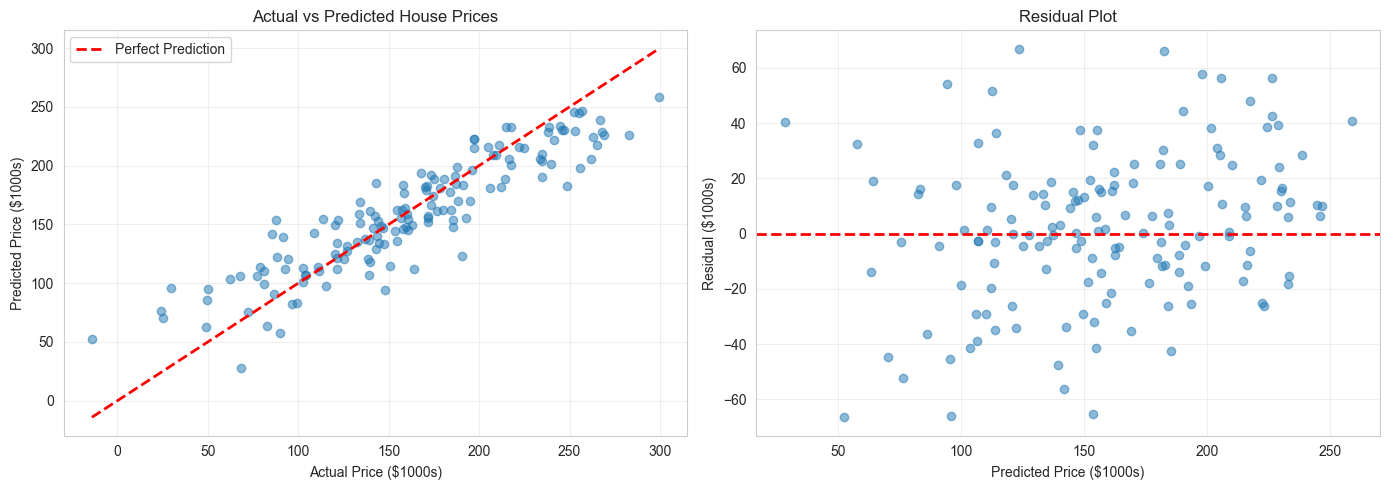


💡 KNN Regression Insights:
  • Predictions are local averages of k neighbors
  • Works well when similar houses have similar prices
  • Piecewise constant predictions (not smooth)
  • Cannot extrapolate beyond training data range


In [13]:
# Train KNN regressor
knn_house = KNeighborsRegressor(
    n_neighbors=7,
    weights='distance',  # Distance weighting better for regression
    metric='euclidean'
)
knn_house.fit(X_train_house_scaled, y_train_house)

# Predictions
y_pred_house = knn_house.predict(X_test_house_scaled)

# Evaluate
r2 = r2_score(y_test_house, y_pred_house)
rmse = np.sqrt(mean_squared_error(y_test_house, y_pred_house))
mae = mean_absolute_error(y_test_house, y_pred_house)

print("\n📈 Performance:")
print(f"  R² Score: {r2:.4f}")
print(f"  RMSE: ${rmse:.2f}k")
print(f"  MAE: ${mae:.2f}k")
print(f"  Mean Price: ${y_test_house.mean():.2f}k")
print(f"  RMSE/Mean: {rmse/y_test_house.mean():.2%}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test_house, y_pred_house, alpha=0.5)
axes[0].plot([y_test_house.min(), y_test_house.max()],
            [y_test_house.min(), y_test_house.max()],
            'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($1000s)')
axes[0].set_ylabel('Predicted Price ($1000s)')
axes[0].set_title('Actual vs Predicted House Prices')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals
residuals_house = y_test_house - y_pred_house
axes[1].scatter(y_pred_house, residuals_house, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price ($1000s)')
axes[1].set_ylabel('Residual ($1000s)')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 KNN Regression Insights:")
print("  • Predictions are local averages of k neighbors")
print("  • Works well when similar houses have similar prices")
print("  • Piecewise constant predictions (not smooth)")
print("  • Cannot extrapolate beyond training data range")


---

## 11. Comparison with Other Algorithms

### When to Choose KNN vs Alternatives

| Aspect | KNN | Decision Trees | Linear Models | SVM | Naive Bayes |
|--------|-----|----------------|---------------|-----|-------------|
| **Interpretability** | ⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐ | ⭐⭐⭐ |
| **Training Speed** | ⭐⭐⭐⭐⭐ (O(1)) | ⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐ | ⭐⭐⭐⭐⭐ |
| **Prediction Speed** | ⭐ (O(n)) | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐⭐⭐ |
| **Memory Usage** | ⭐ (stores all) | ⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐ | ⭐⭐⭐⭐⭐ |
| **Non-linear** | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐ |
| **Feature Scaling** | Required | Not needed | Required | Required | Not needed |
| **High Dimensions** | ⭐ (curse) | ⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐⭐ |
| **Small Data (<1k)** | ⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐⭐⭐ |
| **Large Data (>100k)** | ⭐ (slow) | ⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐ | ⭐⭐⭐⭐ |
| **Overfitting Risk** | Medium (k=1 high) | High | Low | Medium | Low |

### Practical Comparison


In [14]:
# Compare algorithms on classification task
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
import time

print("=" * 60)
print("ALGORITHM COMPARISON - CLASSIFICATION")
print("=" * 60)

classifiers = {
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=7, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': GaussianNB()
}

results_comp = []

for name, clf in classifiers.items():
    # Time training
    start = time.time()
    clf.fit(X_train_clf_scaled, y_train_clf)
    train_time = time.time() - start
    
    # Time prediction
    start = time.time()
    y_pred = clf.predict(X_test_clf_scaled)
    pred_time = time.time() - start
    
    # Metrics
    acc = accuracy_score(y_test_clf, y_pred)
    
    results_comp.append({
        'Algorithm': name,
        'Accuracy': acc,
        'Train Time (ms)': train_time * 1000,
        'Pred Time (ms)': pred_time * 1000
    })

# Display results
df_comp = pd.DataFrame(results_comp)
print("\n" + df_comp.to_string(index=False))

print("\n" + "=" * 60)
print("💡 Key Insights:")
print("=" * 60)
print("✓ KNN:")
print("  • Instant training (just stores data)")
print("  • Slow prediction (O(n) distance calculations)")
print("  • No assumptions about data")
print("  • MUST scale features")
print("\n✓ Decision Tree:")
print("  • Fast training and prediction")
print("  • Handles non-linear patterns")
print("  • No feature scaling needed")
print("\n✓ Logistic Regression:")
print("  • Fastest prediction")
print("  • Good for linear relationships")
print("  • Requires scaling")
print("\n✓ Naive Bayes:")
print("  • Very fast for both")
print("  • Assumes feature independence")


ALGORITHM COMPARISON - CLASSIFICATION

          Algorithm  Accuracy  Train Time (ms)  Pred Time (ms)
          KNN (k=5)      0.86         0.000000        0.000000
      Decision Tree      0.87         3.940821        2.323866
Logistic Regression      0.82         2.009153        0.000000
        Naive Bayes      0.85         0.000000        0.000000

💡 Key Insights:
✓ KNN:
  • Instant training (just stores data)
  • Slow prediction (O(n) distance calculations)
  • No assumptions about data
  • MUST scale features

✓ Decision Tree:
  • Fast training and prediction
  • Handles non-linear patterns
  • No feature scaling needed

✓ Logistic Regression:
  • Fastest prediction
  • Good for linear relationships
  • Requires scaling

✓ Naive Bayes:
  • Very fast for both
  • Assumes feature independence


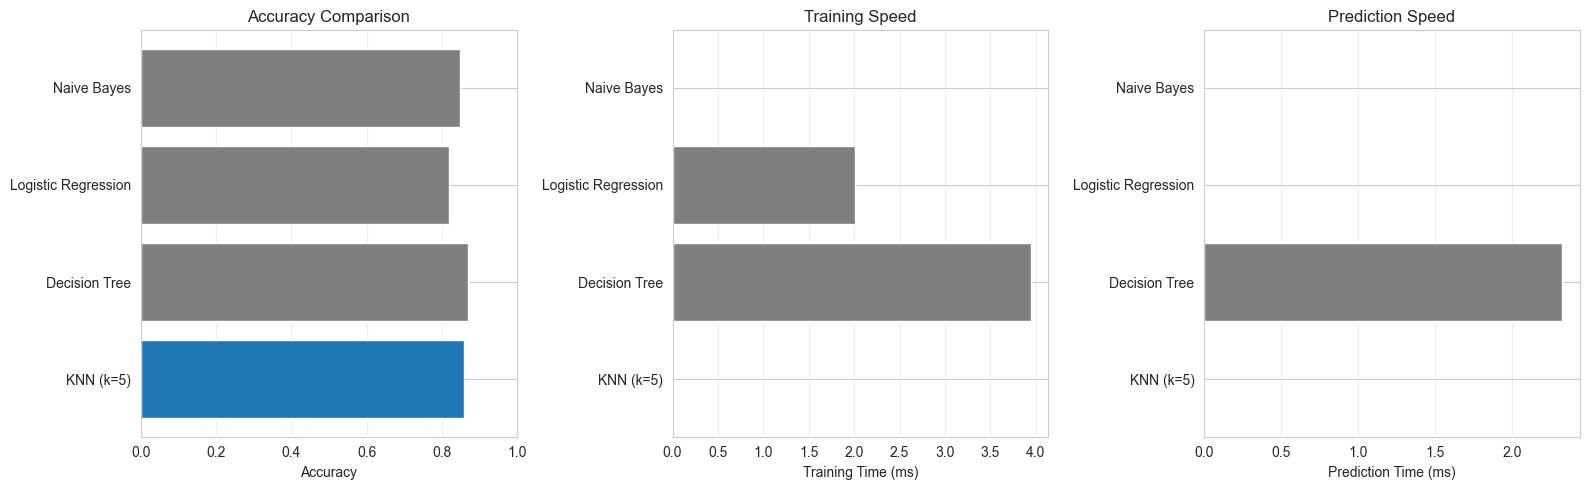


⚠️ Important Tradeoff:
  • KNN: Instant training (0.00ms) but slow prediction (0.00ms)
  • Other models: Training time but fast prediction


In [15]:
# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

algorithms = df_comp['Algorithm']
accuracies = df_comp['Accuracy']
train_times = df_comp['Train Time (ms)']
pred_times = df_comp['Pred Time (ms)']

colors = ['#1f77b4' if 'KNN' in alg else '#7f7f7f' for alg in algorithms]

# Accuracy comparison
axes[0].barh(algorithms, accuracies, color=colors)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Accuracy Comparison')
axes[0].set_xlim([0, 1])
axes[0].grid(True, alpha=0.3, axis='x')

# Training time
axes[1].barh(algorithms, train_times, color=colors)
axes[1].set_xlabel('Training Time (ms)')
axes[1].set_title('Training Speed')
axes[1].grid(True, alpha=0.3, axis='x')

# Prediction time
axes[2].barh(algorithms, pred_times, color=colors)
axes[2].set_xlabel('Prediction Time (ms)')
axes[2].set_title('Prediction Speed')
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n⚠️ Important Tradeoff:")
print(f"  • KNN: Instant training ({train_times.iloc[0]:.2f}ms) but slow prediction ({pred_times.iloc[0]:.2f}ms)")
print(f"  • Other models: Training time but fast prediction")


---

## 12. References

### 📚 Academic Papers & Books

1. **Original Work**:
   - Fix, E., & Hodges, J. L. (1951). "Discriminatory Analysis: Nonparametric Discrimination"
   - Cover, T., & Hart, P. (1967). "Nearest Neighbor Pattern Classification"

2. **Modern Textbooks**:
   - Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (Chapter 13)
   - James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). *An Introduction to Statistical Learning* (Chapter 2)
   - Bishop, C. M. (2006). *Pattern Recognition and Machine Learning* (Chapter 2.5)

3. **Distance Metrics & Optimization**:
   - Bentley, J. L. (1975). "Multidimensional Binary Search Trees Used for Associative Searching"
   - Omohundro, S. M. (1989). "Five Balltree Construction Algorithms"

### 🌐 Online Resources

- [Scikit-learn KNN Documentation](https://scikit-learn.org/stable/modules/neighbors.html)
- [StatQuest: K-Nearest Neighbors](https://www.youtube.com/watch?v=HVXime0nQeI)
- [Interactive KNN Visualization](https://www.cs.toronto.edu/~guerzhoy/321/lec/knn_interp_vis.html)
- [Curse of Dimensionality Explained](https://en.wikipedia.org/wiki/Curse_of_dimensionality)

### 📊 Key Concepts to Master

- **Instance-Based Learning**: No training, just stores data
- **Distance Metrics**: Euclidean, Manhattan, Minkowski, Cosine
- **k Parameter**: Bias-variance tradeoff
- **Weighting**: Uniform vs distance-based
- **Curse of Dimensionality**: Performance degrades in high dimensions
- **KD-Trees & Ball Trees**: Spatial data structures for speed
- **Feature Scaling**: CRITICAL for KNN

### 🔗 Related Notebooks in this Repository

- `01_linear_regression.ipynb` - Parametric alternative for regression
- `02_logistic_regression.ipynb` - Parametric alternative for classification
- `03_decision_trees.ipynb` - Non-parametric alternative (no scaling needed)
- `05_support_vector_machines.ipynb` - Margin-based classifier
- `06_naive_bayes.ipynb` - Probabilistic classifier

### 📈 Evaluation Metrics

**For Classification:**
- Accuracy, Precision, Recall, F1-Score
- Confusion Matrix
- ROC-AUC (using predict_proba)

**For Regression:**
- R², RMSE, MAE
- Residual plots

---

## Summary & Key Takeaways

### What We Learned

1. **Theory**: KNN uses distance to find k nearest neighbors and predicts by voting/averaging
2. **Math**: Multiple distance metrics (Euclidean, Manhattan, etc.)
3. **Assumptions**: Very few! But requires scaled features and low dimensions
4. **Implementation**: Built from scratch (both classifier & regressor) and used scikit-learn
5. **Hyperparameters**: n_neighbors (k) is most important
6. **Tuning**: Cross-validate k, use odd numbers for binary classification
7. **Practice**: Applied to digit recognition and house prices

### When to Use KNN

✅ **Use when**:
- Small to medium datasets (<10k samples)
- No training time constraints
- Non-linear relationships
- Low dimensionality (<20 features)
- Need simple baseline
- Anomaly detection
- Recommendation systems

❌ **Avoid when**:
- Large datasets (>100k) - too slow
- High dimensionality (>50) - curse of dimensionality
- Real-time predictions required
- Memory constrained
- Cannot scale features
- Imbalanced classes (without adjustment)

### Key Differences: Classification vs Regression

| Aspect | KNN Classification | KNN Regression |
|--------|-------------------|----------------|
| **Prediction** | Majority vote | Average/weighted average |
| **Output** | Class label | Continuous value |
| **Weights** | Uniform often good | Distance usually better |
| **Probabilities** | Class proportions | N/A |
| **Typical k** | Odd numbers | Any number |

### Best Practices Checklist

- ✅ **ALWAYS scale features** (StandardScaler)
- ✅ Start with k=5 or k=sqrt(n)
- ✅ Use odd k for binary classification
- ✅ Cross-validate k
- ✅ Try distance weighting
- ✅ Use Ball Tree for large datasets
- ✅ Reduce dimensions if >50 features
- ✅ Consider subsampling if >100k samples

### Critical Requirements

**1. Feature Scaling is MANDATORY:**
```python
# ALWAYS DO THIS!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
```

**2. Choose k Wisely:**
- Too small (k=1): Overfits
- Too large: Underfits
- Rule of thumb: k ≈ sqrt(n_samples)

**3. Mind the Curse of Dimensionality:**
- Performance degrades rapidly >50 features
- Use PCA or feature selection

### Advantages vs Disadvantages

**Advantages:**
- ✅ No training phase (instant)
- ✅ Simple and intuitive
- ✅ Non-parametric (no assumptions)
- ✅ Naturally handles multi-class
- ✅ Works for both classification and regression
- ✅ Good for small datasets
- ✅ Can update easily (just add new data)

**Disadvantages:**
- ❌ Slow predictions (O(n))
- ❌ Memory intensive (stores all data)
- ❌ Requires feature scaling
- ❌ Curse of dimensionality
- ❌ Sensitive to noisy data
- ❌ No model interpretability
- ❌ Cannot extrapolate
- ❌ Poor with imbalanced data

### Unique Characteristic: Lazy Learning

KNN is a **lazy learner** (instance-based):
- No training = instant model creation
- All computation happens at prediction time
- Stores entire training set in memory
- **Opposite of eager learners** (trees, linear models, neural networks)

### Next Steps

1. **Practice** with different distance metrics
2. **Experiment** with k values and cross-validation
3. **Try** high-dimensional data with PCA
4. **Implement** Ball Trees for large datasets
5. **Compare** with other algorithms on your data
6. **Explore** approximate nearest neighbor methods (FAISS, Annoy)
7. **Apply** to recommendation systems or anomaly detection

---

**Congratulations!** You now have a comprehensive understanding of K-Nearest Neighbors for both classification and regression! 🎯🎉

**Remember**: Always scale your features for KNN - it's not optional!